#  Movie Rating Prediction With Python

## CodSoft Data Science Internship - Task 2

###  Objective
The objective of this project is to build a Machine Learning model that predicts movie ratings based on features like genre, director, actors, duration, and votes.

###  Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

###  Machine Learning Algorithm
- Random Forest Regressor

###  Project Workflow
1. Data Loading
2. Data Cleaning
3. Data Preprocessing
4. Feature Engineering
5. Model Training
6. Prediction
7. Accuracy Evaluation

###  Expected Outcome
Predict movie ratings accurately using Machine Learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df = pd.read_csv("IMDb Movies India.csv", encoding='latin1')
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [4]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [5]:
df = df[['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3', 'Rating']]

In [6]:
df.dropna(inplace=True)

In [7]:
df.head()

,Genre,Director,Actor 1,Actor 2,Actor 3,Rating
1,Drama,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,7.0
3,"Comedy, Romance",Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,4.4
5,"Comedy, Drama, Musical",Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,4.7
6,"Drama, Romance, War",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,7.4
8,"Horror, Mystery, Thriller",Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia,5.6


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Genre'] = le.fit_transform(df['Genre'])

df['Director'] = le.fit_transform(df['Director'])

df['Actor 1'] = le.fit_transform(df['Actor 1'])

df['Actor 2'] = le.fit_transform(df['Actor 2'])

df['Actor 3'] = le.fit_transform(df['Actor 3'])

In [11]:

X = df.drop('Rating', axis=1)
y = df['Rating']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.ensemble import RandomForestRegressor

In [14]:
model = RandomForestRegressor()

In [17]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
predictions = model.predict(X_test)

print(predictions)

[5.996 5.63  6.227 ... 6.291 5.334 6.064]


In [19]:
score = model.score(X_test, y_test)

print("Model Score:", score)

Model Score: 0.07093938926608512


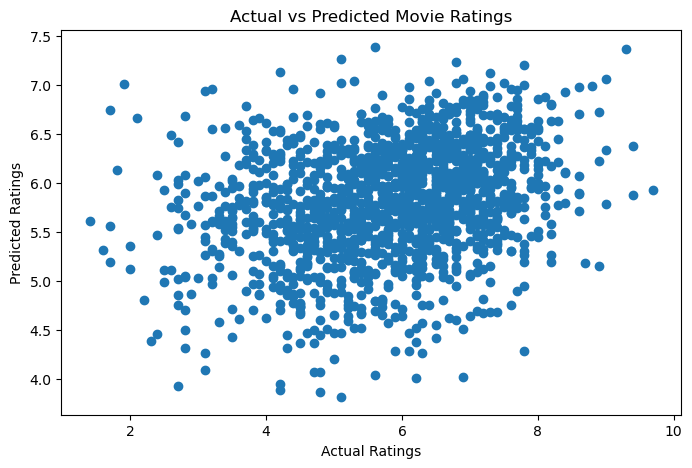

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Ratings")

plt.ylabel("Predicted Ratings")

plt.title("Actual vs Predicted Movie Ratings")

plt.show()

In [21]:
sample = pd.DataFrame(
    [[1, 1, 1, 1, 1]],
    columns=X.columns
)

result = model.predict(sample)

print("Predicted Movie Rating:", result[0])

Predicted Movie Rating: 5.689999999999995


In [22]:
print("Movie Rating Prediction Project Completed Successfully")

print("Final Model Score:", score)

Movie Rating Prediction Project Completed Successfully
Final Model Score: 0.07093938926608512
